# Cardinality Estimation Accuracy Evaluation

This notebook calculates the relative error of estimated cardinalities compared to true values and generates visualization charts.

## Usage

Configure **relative paths from the project root** in the configuration cell below. Supports multiple benchmarks:

Each benchmark configuration includes:
- **Real value path**: Path to the txt file containing true cardinalities (relative path)
- **Estimate paths**: Dictionary of estimated cardinality file paths for different methods (relative paths, key is method name, value is file path)

**Example configuration**:
```python
BENCHMARK_CONFIG = {
    "STATS": {
        "real_path": "experiment/checkpoint/StarCE/card_stats.txt",
        "estimates": {
            "StarCE": "experiment/checkpoint/StarCE/card_stats.txt",
            "SafeBound": "Benchmark/workloads/STATS-CEB/subquery/result/safebound.txt",
        }
    },
    "JOBM": {
        "real_path": "Benchmark/workloads/JOBM/subquery/real_card.txt",
        "estimates": {
            "StarCE": "experiment/checkpoint/StarCE/card_imdb.txt",
            "SafeBound": "Benchmark/workloads/JOBM/subquery/result/safebound.txt",
        }
    }
}
```

In [1]:
# ========== Configuration: Paths (relative to project root) ==========

BENCHMARK_CONFIG = {
    "STATS": {
        "real_path": "Benchmark/workloads/STATS-CEB/subquery/result/real.txt",
        "estimates": {
            "StarCE": "experiment/checkpoint/StarCE/card_stats.txt",
            "StarCE-upper": "experiment/checkpoint/StarCE/pred_method/STATS/card_STATS_PAR1.0.txt",
            "SafeBound": "experiment/checkpoint/SafeBound/SafeBound_3_Stats_evaluate_results.txt",
            "DuckDB": "experiment/checkpoint/DuckDB/card_stats.txt",
            "Postgre": "experiment/checkpoint/Postgre/card_stats.txt",
            "FactorJoin": "experiment/checkpoint/FactorJoin/card_stats.txt",
            "BayesCard": "Benchmark/workloads/STATS-CEB/subquery/result/bayescard.txt",
            "Flat": "Benchmark/workloads/STATS-CEB/subquery/result/flat.txt",
            "DeepDB": "Benchmark/workloads/STATS-CEB/subquery/result/deepdb.txt",
            "NeuroCard": "Benchmark/workloads/STATS-CEB/subquery/result/neurocard.txt",
            "LpBound": "Benchmark/workloads/STATS-CEB/subquery/result/lpbound.txt",
        }
    },
    "JOBM": {
        "real_path": "Benchmark/workloads/JOBM/subquery/result/real.txt",
        "estimates": {
            "StarCE": "experiment/checkpoint/StarCE/card_jobm.txt",
            "StarCE-upper": "experiment/checkpoint/StarCE/pred_method/JOBM/card_JOBM_PAR1.0.txt",
            "SafeBound": "experiment/checkpoint/SafeBound/SafeBound_3_JOBM_evaluate_results.txt",
            "DuckDB": "experiment/checkpoint/DuckDB/card_jobm.txt",
            "Postgre": "experiment/checkpoint/Postgre/card_jobm.txt",
            "FactorJoin": "experiment/checkpoint/FactorJoin/card_jobm.txt",
        }
    },
    "JobJoin": {
        "real_path": "Benchmark/workloads/JobJoin/result/real.txt",
        "estimates": {
            "StarCE": "experiment/checkpoint/StarCE/card_jobjoin.txt",
            "StarCE-upper": "experiment/checkpoint/StarCE/card_jobjoin.txt",
            "SafeBound": "Benchmark/workloads/JobJoin/result/safebound.txt",
            "DuckDB": "Benchmark/workloads/JobJoin/result/duckdb.txt",
            "Postgre": "Benchmark/workloads/JobJoin/result/postgres.txt",
            "FactorJoin": "Benchmark/workloads/JobJoin/result/factorjoin.txt",
            "LpBound": "Benchmark/workloads/JobJoin/result/lpbound.txt",
        }
    },
    "StatsJoin": {
        "real_path": "Benchmark/workloads/StatsJoin/subquery/result/real.txt",
        "estimates": {
            "StarCE": "Benchmark/workloads/StatsJoin/subquery/result/starce.txt",
            "StarCE-upper": "Benchmark/workloads/StatsJoin/subquery/result/starce.txt",
            "SafeBound": "Benchmark/workloads/StatsJoin/subquery/result/safebound.txt",
            "DuckDB": "Benchmark/workloads/StatsJoin/subquery/result/duckdb.txt",
            "Postgre": "Benchmark/workloads/StatsJoin/subquery/result/postgres.txt",
            "FactorJoin": "Benchmark/workloads/StatsJoin/subquery/result/factorjoin.txt",
            "LpBound": "Benchmark/workloads/StatsJoin/subquery/result/lpbound.txt",
            "BayesCard": "Benchmark/workloads/StatsJoin/subquery/result/bayescard.txt",
        }
    },
    "JOBLight": {
        "real_path": "Benchmark/workloads/JOBLight/subquery/result/real.txt",
        "estimates": {
            "StarCE": "experiment/checkpoint/StarCE/card_joblight.txt",
            "StarCE-upper": "experiment/checkpoint/StarCE/pred_method/JOBLight/card_JOBLight_PAR1.0.txt",
            "SafeBound": "experiment/checkpoint/SafeBound/SafeBound_3_JOBLight_evaluate_results.txt",
            "DuckDB": "experiment/checkpoint/DuckDB/card_joblight.txt",
            "Postgre": "experiment/checkpoint/Postgre/card_joblight.txt",
            "FactorJoin": "experiment/checkpoint/FactorJoin/card_joblight.txt",
            "BayesCard": "Benchmark/workloads/JOBLight/subquery/result/bayescard.txt",
            "Flat": "Benchmark/workloads/JOBLight/subquery/result/flat.txt",
            "DeepDB": "Benchmark/workloads/JOBLight/subquery/result/deepdb.txt",
            "NeuroCard": "Benchmark/workloads/JOBLight/subquery/result/neurocard.txt",
            "LpBound": "Benchmark/workloads/JOBLight/subquery/result/lpbound.txt",
        }
    },
    "JOBLightRanges": {
        "real_path": "Benchmark/workloads/JOBLightRanges/subquery/result/real.txt",
        "estimates": {
            "StarCE": "experiment/checkpoint/StarCE/card_joblr.txt",
            "StarCE-upper": "experiment/checkpoint/StarCE/pred_method/JOBLightRanges/card_JOBLightRanges_PAR1.0.txt",
            "SafeBound": "experiment/checkpoint/SafeBound/SafeBound_3_JOBLightRanges_evaluate_results.txt",
            "DuckDB": "experiment/checkpoint/DuckDB/card_joblr.txt",
            "Postgre": "experiment/checkpoint/Postgre/card_joblr.txt",
            "FactorJoin": "experiment/checkpoint/FactorJoin/card_joblr.txt",
            "LpBound": "Benchmark/workloads/JOBLightRanges/subquery/result/lpbound.txt",
            "BayesCard": "Benchmark/workloads/JOBLightRanges/subquery/result/bayescard.txt",
        }
    }
}

# ========== Processing ==========
import os, sys
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.colors import to_hex
from pathlib import Path
from collections import defaultdict

def get_project_root():
    cwd = Path.cwd()
    for parent in [cwd] + list(cwd.parents):
        if (parent / "Benchmark").exists() and (parent / "experiment").exists():
            return parent
    if "experiment" in str(cwd):
        return cwd.parent
    if (cwd / "Benchmark").exists() or (cwd / "experiment").exists():
        return cwd
    return cwd

PROJECT_ROOT = get_project_root()
print(f"Project root: {PROJECT_ROOT}\n")

def resolve_path(p):
    return Path(p) if os.path.isabs(p) else (PROJECT_ROOT / p).resolve()

def read_txt_file(fp):
    vals, miss = [], 0
    with open(fp) as f:
        for l in f:
            s = l.strip()
            if not s: continue
            if s.upper() == 'MISSING':
                vals.append(None); miss += 1
            else:
                vals.append(float(s))
    if miss: print(f"  Note: {miss} MISSING in {fp}")
    return vals

all_error_data = {}
for bm, cfg in BENCHMARK_CONFIG.items():
    print(f"=== {bm} ===")
    rp = resolve_path(cfg["real_path"])
    if not rp.exists():
        print(f"  real not found: {rp}\n"); continue
    tv = read_txt_file(rp)
    print(f"  real: {len(tv)} rows")
    bm_err = {}
    for mn, ep in cfg["estimates"].items():
        ap = resolve_path(ep)
        if not ap.exists():
            print(f"  {mn}: not found"); continue
        dv = read_txt_file(ap)
        if len(dv) != len(tv):
            print(f"  {mn}: rows mismatch ({len(dv)} vs {len(tv)})"); continue
        rel = []
        skip = 0
        for t, d in zip(tv, dv):
            if d is None: skip += 1; continue
            rel.append(max(1, d) / max(1, t))
        if rel:
            bm_err[mn] = rel
            extra = f" ({skip} MISSING skipped)" if skip else ""
            print(f"  {mn}: {len(rel)} errors{extra}")
        else:
            print(f"  {mn}: all {skip} MISSING")
    if bm_err:
        all_error_data[bm] = bm_err
        print(f"  -> {len(bm_err)} methods\n")
    else:
        print(f"  -> no valid methods\n")

if not all_error_data:
    raise ValueError("No valid data")

print(f"Total: {len(all_error_data)} benchmarks")

OUTPUT_DIR = PROJECT_ROOT / "experiment" / "checkpoint" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Project root: /home/liwei/starce-final/StarCE

=== STATS ===
  real: 2471 rows
  StarCE: 2471 errors
  StarCE-upper: 2471 errors
  SafeBound: 2471 errors
  DuckDB: 2471 errors
  Postgre: 2471 errors
  FactorJoin: 2471 errors
  BayesCard: 2471 errors
  Flat: 2471 errors
  DeepDB: 2471 errors
  NeuroCard: 2471 errors
  LpBound: 2471 errors
  -> 11 methods

=== JOBM ===
  real: 6424 rows
  StarCE: 6424 errors
  StarCE-upper: 6424 errors
  SafeBound: 6424 errors
  DuckDB: 6424 errors
  Postgre: 6424 errors
  FactorJoin: 6424 errors
  -> 6 methods

=== JobJoin ===
  real: 31 rows
  StarCE: 31 errors
  StarCE-upper: 31 errors
  SafeBound: 31 errors
  DuckDB: 31 errors
  Postgre: 31 errors
  FactorJoin: 31 errors
  LpBound: 31 errors
  -> 7 methods

=== StatsJoin ===
  real: 226 rows
  StarCE: 226 errors
  StarCE-upper: 226 errors
  SafeBound: 226 errors
  DuckDB: 226 errors
  Postgre: 226 errors
  FactorJoin: 226 errors
  LpBound: 226 errors
  BayesCard: 226 errors
  -> 8 methods

=== JOBLig

In [2]:
# ========== Unified style: colors, ordering, violin helper ==========
import sys, os
sys.path.append(os.path.abspath('.'))
import plot_style

# Per-benchmark method ordering follows plot_style.METHOD_ORDER (StarCE first),
# compared via display names so case/alias variants (e.g. 'StarCE-upper',
# 'postgres') still land in the right slot. Unknown methods sort to the end.
order_index = {name: i for i, name in enumerate(plot_style.METHOD_ORDER)}

def ordered_methods_for(benchmark_name):
    ms = [m for m in all_error_data[benchmark_name] if all_error_data[benchmark_name][m]]
    known = sorted((m for m in ms if plot_style.method_display_name(m) in order_index),
                   key=lambda m: order_index[plot_style.method_display_name(m)])
    unknown = sorted(m for m in ms if plot_style.method_display_name(m) not in order_index)
    return known + unknown

benchmark_methods = {}
for benchmark_name in all_error_data:
    methods = ordered_methods_for(benchmark_name)
    if methods:
        benchmark_methods[benchmark_name] = methods

plt.rcParams.update({
    'font.size': 15,
    'axes.titlesize': 18,
    'axes.labelsize': 17,
    'xtick.labelsize': 15,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
})


def plot_accuracy_violin(benchmark_subset, output_filename, group_gap=1.0, top_pad_extra=0.0,
                         violin_width=0.5, fig_h=5.5, legend_ncol=None):
    """Grouped violin plot of log10 relative error for a subset of benchmarks.

    Layout is self-contained per figure: each violin occupies one data unit and
    the figure width scales with the actual number of violins, so violins keep a
    consistent physical width regardless of subset size. ``violin_width`` (< the
    1.0 unit spacing) controls how thin the bodies are and how big the gaps
    between them are; ``fig_h`` sets the physical figure height (vertical
    compression, independent of the y data range). StarCE is emphasized (opaque
    + thick edge). The y-range spans the full data (every point shown);
    ``top_pad_extra`` adds extra headroom above the max. The legend sits above
    the axes; the figure is then widened so the axes are at least as wide as the
    legend, avoiding the side whitespace bbox_inches='tight' would otherwise
    leave.
    """
    benchmarks = [b for b in benchmark_subset if b in benchmark_methods]
    if not benchmarks:
        print(f"{output_filename}: no benchmark data, skipped")
        return

    # Legend method universe for this figure, preserving METHOD_ORDER.
    seen = []
    for b in benchmarks:
        for m in benchmark_methods[b]:
            if m not in seen:
                seen.append(m)
    legend_methods = sorted(seen, key=lambda m: order_index.get(
        plot_style.method_display_name(m), len(order_index)))

    slot = 1.0  # data-unit spacing between adjacent violins within a group
    positions, violin_data, violin_colors, emphasize = [], [], [], []
    benchmark_centers, benchmark_labels, separators = [], [], []

    cursor = 0.0
    for benchmark_name in benchmarks:
        methods = benchmark_methods[benchmark_name]
        xs = cursor + np.arange(len(methods)) * slot
        for x, method_name in zip(xs, methods):
            errors = np.array(all_error_data[benchmark_name][method_name])
            log_errors = np.log10(np.maximum(errors, 1e-10))
            positions.append(float(x))
            violin_data.append(log_errors)
            violin_colors.append(plot_style.get_method_color(method_name))
            emphasize.append(plot_style.method_display_name(method_name) == 'StarCE')
        benchmark_centers.append(float(xs.mean()))
        benchmark_labels.append(benchmark_name)
        separators.append(float(xs[-1] + (slot + group_gap) / 2))
        cursor = xs[-1] + slot + group_gap
    separators.pop()

    total_violins = len(positions)
    fig_w = max(7.5, total_violins * 0.42 + (len(benchmarks) - 1) * 0.4)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    plot_style.draw_violins(ax, violin_data, positions, violin_colors,
                            widths=violin_width, emphasize_mask=emphasize)

    # y spans the full data range so every value is shown (no clipping);
    # top_pad_extra adds extra headroom above the max when requested.
    all_log_values = np.concatenate(violin_data)
    lo = float(all_log_values.min())
    hi = float(all_log_values.max())
    ax.set_ylim(lo - 0.5, hi + 0.5 + top_pad_extra)
    ax.set_xlim(positions[0] - 0.8, positions[-1] + 0.8)
    ax.set_ylabel("Relative Error (log10)")
    ax.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
    for sep in separators:
        ax.axvline(x=sep, color="#333333", linestyle="--", linewidth=0.7)
    ax.set_xticks(benchmark_centers)
    ax.set_xticklabels(benchmark_labels)

    # Legend above the axes. When legend_ncol is not specified, auto-wrap
    # to at most 6 columns; otherwise use the given value (e.g. 11 for a
    # single-row legend on the combined plot).
    ncol = legend_ncol if legend_ncol is not None else min(len(legend_methods), 6)
    legend_handles = [
        mpl.patches.Patch(color=plot_style.get_method_color(m),
                          label=plot_style.method_display_name(m))
        for m in legend_methods
    ]
    legend = ax.legend(handles=legend_handles, loc="lower center",
                       bbox_to_anchor=(0.5, 1.01), ncol=ncol, framealpha=0.9,
                       borderaxespad=0.0)

    # Widen the figure so the axes are >= the legend width (fills the space the
    # legend spans instead of leaving side margins after bbox_inches='tight').
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    leg_w = legend.get_window_extent(renderer).width / fig.dpi
    ax_w = ax.get_window_extent(renderer).width / fig.dpi
    if leg_w > ax_w + 0.05:
        fig_w = fig_w + (leg_w - ax_w) + 0.2
        fig.set_size_inches(fig_w, fig_h)

    output_file = OUTPUT_DIR / output_filename
    plt.savefig(output_file, bbox_inches="tight")
    print(f"Saved: {output_file}  (figsize {fig_w:.1f}x{fig_h:.1f}, ylim [{lo-0.5:.1f}, {hi+0.5+top_pad_extra:.1f}])")
    plt.show()


print(f"Prepared {len(benchmark_methods)} benchmarks:")
for b, ms in benchmark_methods.items():
    print(f"  {b}: {[plot_style.method_display_name(m) for m in ms]}")

Prepared 6 benchmarks:
  STATS: ['StarCE', 'StarCE-Upper', 'DuckDB', 'Postgres', 'SafeBound', 'LpBound', 'BayesCard', 'FactorJoin', 'DeepDB', 'Flat', 'NeuroCard']
  JOBM: ['StarCE', 'StarCE-Upper', 'DuckDB', 'Postgres', 'SafeBound', 'FactorJoin']
  JobJoin: ['StarCE', 'StarCE-Upper', 'DuckDB', 'Postgres', 'SafeBound', 'LpBound', 'FactorJoin']
  StatsJoin: ['StarCE', 'StarCE-Upper', 'DuckDB', 'Postgres', 'SafeBound', 'LpBound', 'BayesCard', 'FactorJoin']
  JOBLight: ['StarCE', 'StarCE-Upper', 'DuckDB', 'Postgres', 'SafeBound', 'LpBound', 'BayesCard', 'FactorJoin', 'DeepDB', 'Flat', 'NeuroCard']
  JOBLightRanges: ['StarCE', 'StarCE-Upper', 'DuckDB', 'Postgres', 'SafeBound', 'LpBound', 'BayesCard', 'FactorJoin']


Saved: /home/liwei/starce-final/StarCE/experiment/checkpoint/figures/accuracy_violin_joins.pdf  (figsize 11.7x5.5, ylim [-7.9, 6.8])


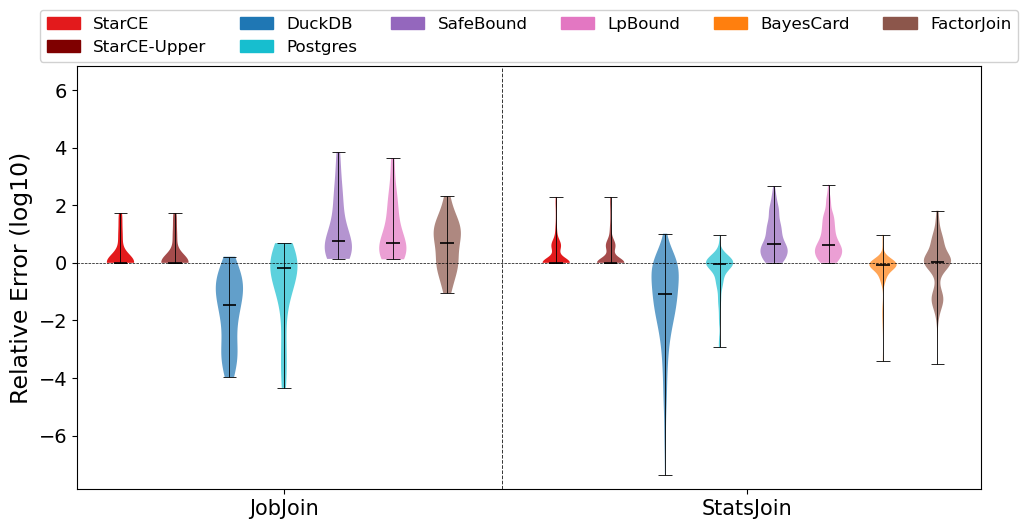

In [3]:
# Accuracy on pure-join benchmarks (no predicates): JobJoin, StatsJoin
plot_accuracy_violin(['JobJoin', 'StatsJoin'], 'accuracy_violin_joins.pdf', top_pad_extra=2.5)


Saved: /home/liwei/starce-final/StarCE/experiment/checkpoint/figures/accuracy_violin_predicates.pdf  (figsize 16.3x5.5, ylim [-10.1, 12.9])


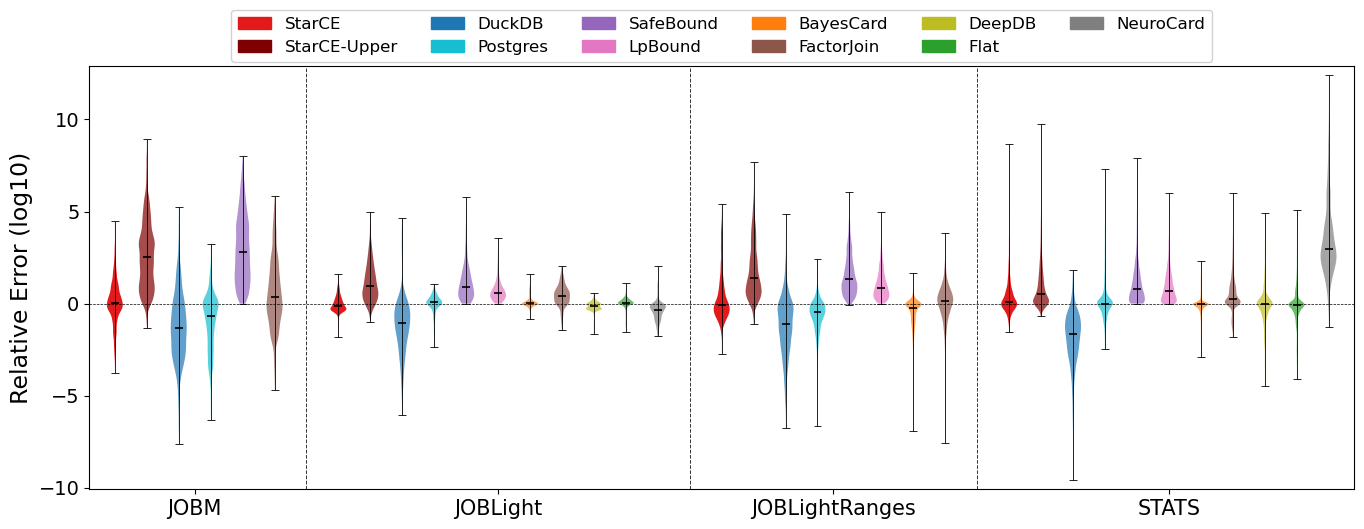

In [4]:
# Accuracy on predicated benchmarks: JOBM, JOBLight, JOBLightRanges, STATS
plot_accuracy_violin(['JOBM', 'JOBLight', 'JOBLightRanges', 'STATS'],
                     'accuracy_violin_predicates.pdf')

Saved: /home/liwei/starce-final/StarCE/experiment/checkpoint/figures/accuracy_violin_all.pdf  (figsize 23.4x5.5, ylim [-10.1, 12.9])


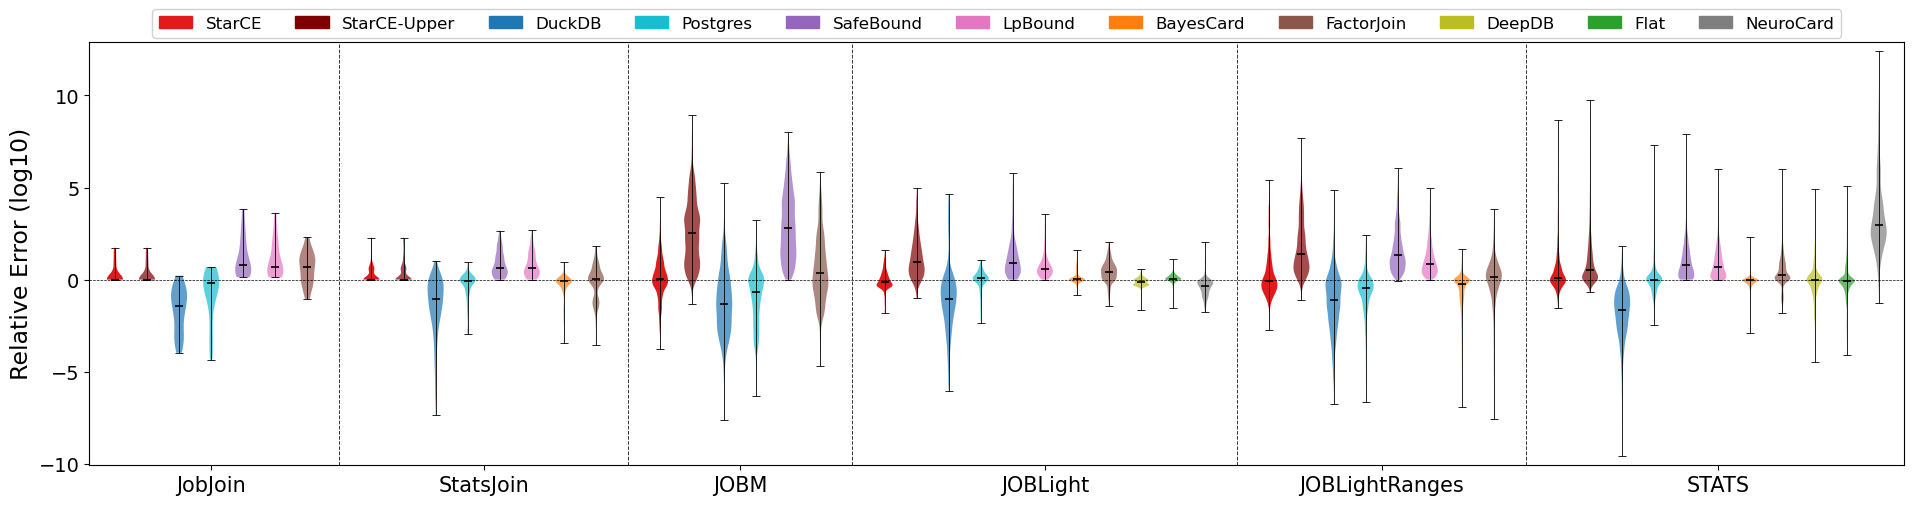

In [5]:
# Combined plot: all 6 benchmarks, single-row legend
plot_accuracy_violin(['JobJoin', 'StatsJoin', 'JOBM', 'JOBLight', 'JOBLightRanges', 'STATS'],
                     'accuracy_violin_all.pdf', legend_ncol=11)